In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [224]:
data=pd.read_csv("DS_Data.csv")

In [225]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Employee_ID      400 non-null    str    
 1   Age              384 non-null    float64
 2   Experience       384 non-null    float64
 3   Education_Years  380 non-null    float64
 4   Projects         390 non-null    float64
 5   Certifications   382 non-null    float64
 6   Coding_Hours     376 non-null    float64
 7   Communication    378 non-null    float64
 8   Problem_Solving  385 non-null    float64
 9   Attendance       388 non-null    float64
 10  Internships      385 non-null    float64
 11  Python           378 non-null    float64
 12  SQL              374 non-null    float64
 13  ML               380 non-null    float64
 14  Cloud            387 non-null    float64
 15  Gender           376 non-null    str    
 16  Department       382 non-null    str    
 17  City             380 non-nu

In [226]:
data.columns

Index(['Employee_ID', 'Age', 'Experience', 'Education_Years', 'Projects',
       'Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving',
       'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Gender',
       'Department', 'City', 'Work_Mode', 'Salary', 'Promotion'],
      dtype='str')

In [227]:
data.isnull().sum()

Employee_ID         0
Age                16
Experience         16
Education_Years    20
Projects           10
Certifications     18
Coding_Hours       24
Communication      22
Problem_Solving    15
Attendance         12
Internships        15
Python             22
SQL                26
ML                 20
Cloud              13
Gender             24
Department         18
City               20
Work_Mode          29
Salary              0
Promotion           0
dtype: int64

In [228]:
data.sample()

,Employee_ID,Age,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,...,Python,SQL,ML,Cloud,Gender,Department,City,Work_Mode,Salary,Promotion
152,EMP3253,32.0,10.0,17.0,13.0,3.0,26.0,71.0,93.0,84.4,...,10.0,1.0,10.0,3.0,Female,AI,Hyderabad,Office,117377,1


In [229]:
data=data.drop(["Age","City"], axis=1)

In [230]:
data.sample()

,Employee_ID,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,Internships,Python,SQL,ML,Cloud,Gender,Department,Work_Mode,Salary,Promotion
2,EMP9265,17.0,15.0,22.0,5.0,30.0,67.0,54.0,76.3,4.0,6.0,NaN,1.0,4.0,Female,BI,Remote,133252,1


In [231]:
num=[]
cat=[]
for i in data.columns:
    if data[i].dtype=="str":
        cat.append(i)
    else:
        num.append(i)
print("num",num)
print("cat",cat)

num ['Experience', 'Education_Years', 'Projects', 'Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving', 'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Salary', 'Promotion']
cat ['Employee_ID', 'Gender', 'Department', 'Work_Mode']


In [232]:
data[num].isnull().sum()

Experience         16
Education_Years    20
Projects           10
Certifications     18
Coding_Hours       24
Communication      22
Problem_Solving    15
Attendance         12
Internships        15
Python             22
SQL                26
ML                 20
Cloud              13
Salary              0
Promotion           0
dtype: int64

In [233]:
num_cols=['Experience', 'Education_Years', 'Projects', 'Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving', 'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud']
data[num_cols]=data[num_cols].fillna(data[num_cols].mean())

In [234]:
data[num].isnull().sum()

Experience         0
Education_Years    0
Projects           0
Certifications     0
Coding_Hours       0
Communication      0
Problem_Solving    0
Attendance         0
Internships        0
Python             0
SQL                0
ML                 0
Cloud              0
Salary             0
Promotion          0
dtype: int64

In [235]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Experience: 0 outliers
Education_Years: 0 outliers
Projects: 0 outliers
Certifications: 0 outliers
Coding_Hours: 0 outliers
Communication: 0 outliers
Problem_Solving: 0 outliers
Attendance: 0 outliers
Internships: 0 outliers
Python: 0 outliers
SQL: 0 outliers
ML: 0 outliers
Cloud: 0 outliers
Salary: 0 outliers
Promotion: 0 outliers


In [236]:
data.sample()

,Employee_ID,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,Internships,Python,SQL,ML,Cloud,Gender,Department,Work_Mode,Salary,Promotion
314,EMP7440,9.0,18.0,24.0,4.0,12.0,95.0,95.0,97.6,0.0,8.0,8.0,9.0,7.0,Female,Analytics,Remote,118167,1


In [237]:
data[cat].isnull().sum()

Employee_ID     0
Gender         24
Department     18
Work_Mode      29
dtype: int64

In [238]:
cat_cols=['Employee_ID', 'Gender', 'Department', 'Work_Mode']
data[cat_cols]=data[cat_cols].fillna(data[cat_cols].mode())

In [239]:
data['Department'].mode()
data['Department']=data['Department'].fillna("AI")

data['Work_Mode'].mode()
data['Work_Mode']=data['Work_Mode'].fillna("Hybrid")

In [240]:
data[cat].isnull().sum()

Employee_ID     0
Gender         24
Department      0
Work_Mode       0
dtype: int64

In [241]:
data.sample()

,Employee_ID,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,Internships,Python,SQL,ML,Cloud,Gender,Department,Work_Mode,Salary,Promotion
94,EMP9046,16.0,19.0,30.0,6.0,12.0,76.0,59.0,74.4,4.0,1.0,10.0,10.0,2.0,NaN,Data Science,Office,152426,1


In [242]:
data.isnull().sum()

Employee_ID         0
Experience          0
Education_Years     0
Projects            0
Certifications      0
Coding_Hours        0
Communication       0
Problem_Solving     0
Attendance          0
Internships         0
Python              0
SQL                 0
ML                  0
Cloud               0
Gender             24
Department          0
Work_Mode           0
Salary              0
Promotion           0
dtype: int64

In [243]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

# PLOTS

In [244]:
cat

['Employee_ID', 'Gender', 'Department', 'Work_Mode']

In [245]:
num

['Experience',
 'Education_Years',
 'Projects',
 'Certifications',
 'Coding_Hours',
 'Communication',
 'Problem_Solving',
 'Attendance',
 'Internships',
 'Python',
 'SQL',
 'ML',
 'Cloud',
 'Salary',
 'Promotion']

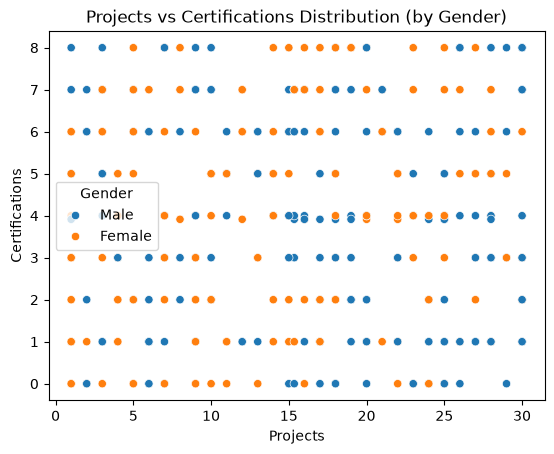

In [246]:
sns.scatterplot(data=data, x="Projects", y="Certifications", hue="Gender")
plt.title("Projects vs Certifications Distribution (by Gender)")
plt.show()

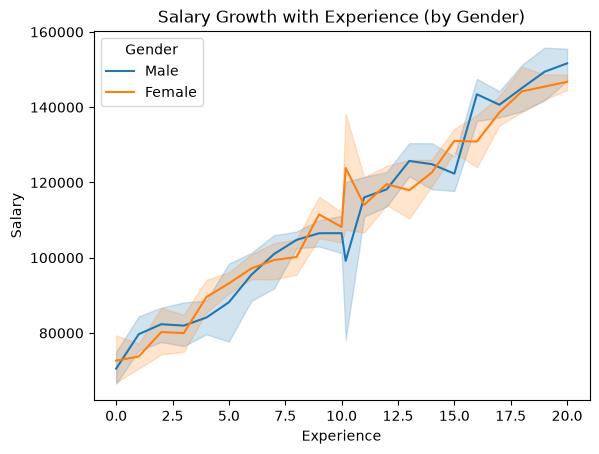

In [247]:
sns.lineplot(data=data, x='Experience', y='Salary', hue='Gender')
plt.title("Salary Growth with Experience (by Gender)")
plt.show()

/tmp/ipykernel_6020/2427802188.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Department", y="Salary",data=data, palette="pastel")


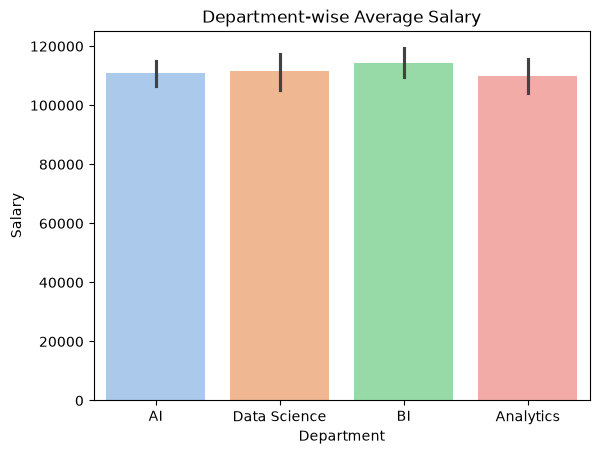

In [248]:
sns.barplot(x="Department", y="Salary",data=data, palette="pastel")
plt.title("Department-wise Average Salary")
plt.show()

In [249]:
cat


['Employee_ID', 'Gender', 'Department', 'Work_Mode']

In [250]:
num

['Experience',
 'Education_Years',
 'Projects',
 'Certifications',
 'Coding_Hours',
 'Communication',
 'Problem_Solving',
 'Attendance',
 'Internships',
 'Python',
 'SQL',
 'ML',
 'Cloud',
 'Salary',
 'Promotion']

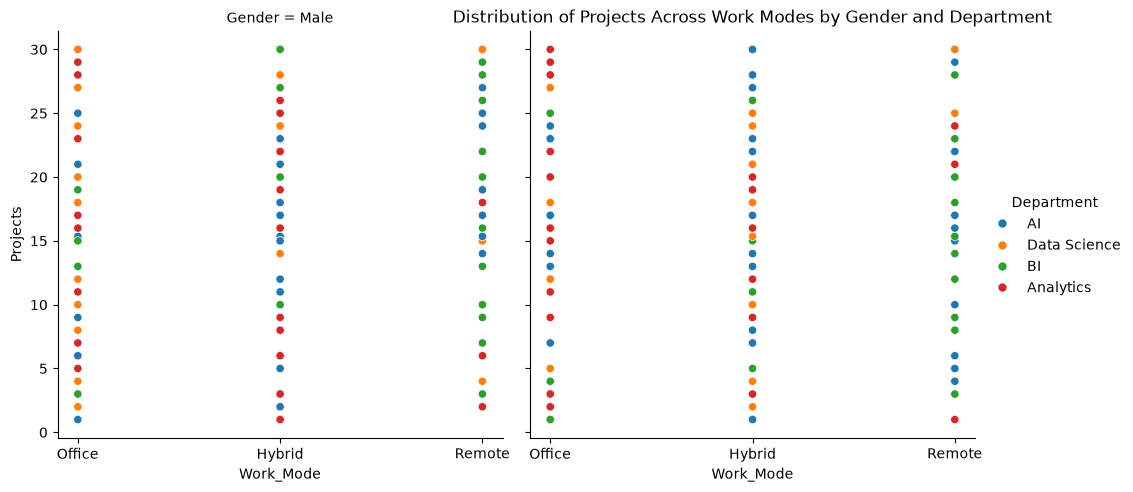

In [251]:
sns.relplot(data=data, x='Work_Mode', y='Projects', col='Gender', hue='Department')
plt.title("Distribution of Projects Across Work Modes by Gender and Department")
plt.show()

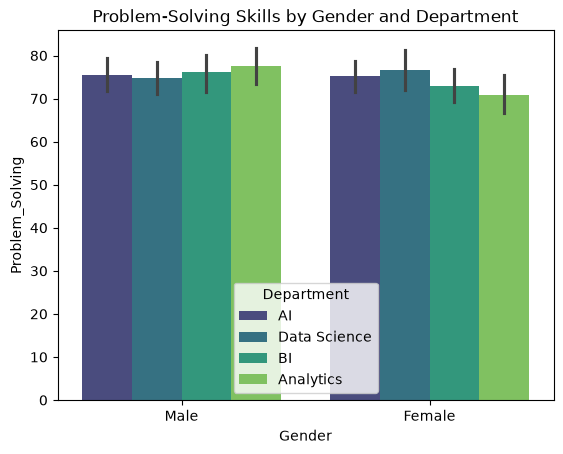

In [252]:
sns.barplot(data=data, x='Gender', y='Problem_Solving', hue='Department', palette='viridis')
plt.title("Problem-Solving Skills by Gender and Department")
plt.show()

In [253]:
num

['Experience',
 'Education_Years',
 'Projects',
 'Certifications',
 'Coding_Hours',
 'Communication',
 'Problem_Solving',
 'Attendance',
 'Internships',
 'Python',
 'SQL',
 'ML',
 'Cloud',
 'Salary',
 'Promotion']

In [254]:
cat

['Employee_ID', 'Gender', 'Department', 'Work_Mode']

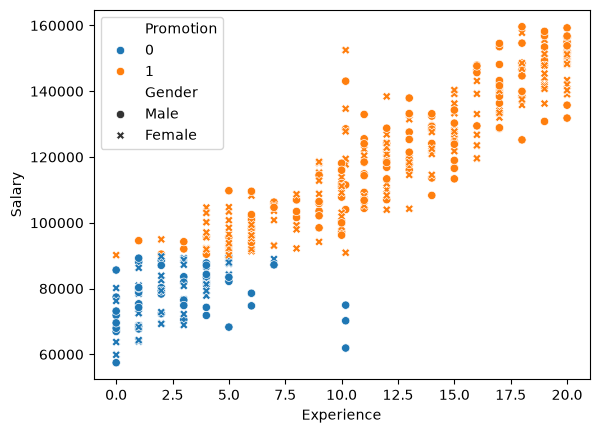

In [255]:
sns.scatterplot(data=data, x="Experience",y="Salary",hue="Promotion",style="Gender")
plt.show()

# ML

In [256]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [257]:
for i in data.columns:
    if data[i].dtype=='str':
        data[i]=LE.fit_transform(data[i])
    else:
        pass


In [258]:
data.sample()

,Employee_ID,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,Internships,Python,SQL,ML,Cloud,Gender,Department,Work_Mode,Salary,Promotion
215,291,3.0,20.0,6.0,1.0,14.0,69.0,76.0,90.4,0.0,5.0,10.0,3.0,6.0,1,3,0,76492,0


In [259]:
data.columns

Index(['Employee_ID', 'Experience', 'Education_Years', 'Projects',
       'Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving',
       'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Gender',
       'Department', 'Work_Mode', 'Salary', 'Promotion'],
      dtype='str')

# Linear

In [260]:
x=data.iloc[:,1: -2]

y=data['Salary']

In [261]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [262]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [263]:
LR.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[3999.71,1076.28, 527.81,...,-953.89, 252.04,-680.35]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['Experience','Education_Years','Projects',...,'Gender','Department', 'Work_Mode']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.857e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [264]:
predict=LR.predict(x_test)

In [265]:
LR.score(x_test,y_test)

0.9806500868144634

In [266]:
data.sample()

,Employee_ID,Experience,Education_Years,Projects,Certifications,Coding_Hours,Communication,Problem_Solving,Attendance,Internships,Python,SQL,ML,Cloud,Gender,Department,Work_Mode,Salary,Promotion
62,65,0.0,15.0,30.0,3.0,30.0,65.0,85.0,79.6,2.0,4.0,7.0,2.0,8.0,0,1,0,72846,0


# LOG


In [267]:
data.columns

Index(['Employee_ID', 'Experience', 'Education_Years', 'Projects',
       'Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving',
       'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Gender',
       'Department', 'Work_Mode', 'Salary', 'Promotion'],
      dtype='str')

In [268]:
x=data.loc[:,['Experience', 'Education_Years', 'Projects','Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving', 'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Gender', 'Department', 'Work_Mode', 'Promotion']]

y=data['Promotion']

In [269]:
from sklearn.linear_model import LogisticRegression
LGR=LogisticRegression()

In [270]:
LGR.fit(x,y)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [271]:
pred=LGR.predict(x)

In [272]:
LGR.score(x,y)

0.9975

In [273]:
import joblib
joblib.dump(LE,"LabelE.pkl")
joblib.dump(LGR,"LOGreg.pkl")

['LOGreg.pkl']

In [274]:
import joblib
LE=joblib.load("LabelE.pkl")
LOGR=joblib.load("LOGreg.pkl")

In [286]:
# Numerical Inputs
Experience = float(input("Enter Experience (years): "))
Education_Years = int(input("Enter Education Years: "))
Projects = int(input("Enter Number of Projects: "))
Certifications = int(input("Enter Number of Certifications: "))
Coding_Hours = float(input("Enter Coding Hours per Week: "))
Communication = float(input("Enter Communication Score: "))
Problem_Solving = float(input("Enter Problem Solving Score: "))
Attendance = float(input("Enter Attendance Percentage: "))
Internships = int(input("Enter Number of Internships: "))
Python = float(input("Enter Python Skill Score: "))
SQL = float(input("Enter SQL Skill Score: "))
ML = float(input("Enter Machine Learning Skill Score: "))
Cloud = float(input("Enter Cloud Skill Score: "))

# Categorical Inputs
Gender = input("Enter Gender (Male/Female): ")
Department = input("Enter Department (Data Science, AI, Software, etc.): ")
Work_Mode = input("Enter Work Mode (Remote/Hybrid/Office): ")

In [287]:
x=data.loc[:,['Experience', 'Education_Years', 'Projects','Certifications', 'Coding_Hours', 'Communication', 'Problem_Solving', 'Attendance', 'Internships', 'Python', 'SQL', 'ML', 'Cloud', 'Gender', 'Department', 'Work_Mode', 'Promotion']]
y=data['Promotion']


In [289]:
pred=LGR.predict(x)

In [296]:
if pred[0]==1:
    print("Yes!, Promoted")
else:
    print("No!, Not Promoted")

Yes!, Promoted
